# PCA review follow-up — direct tests of what the eigenvector agreement does and does not show

A reviewer of `PCA_Eigenvector_Report.docx` accepted the fusion approach but challenged five parts of the reasoning: (1) similar eigenvectors do not establish accurate OD flows and the four charted components explain only part of the variance; (2) "the divergence is on the diagonal" needs a direct test on the conditional outbound distributions; (3) "noise changes eigenvalues, not eigenvectors" was asserted, not demonstrated — a strong diagonal can flatten a spectrum by itself, and two survey days from the same households are not independent; (4) superzone agreement says nothing about within-superzone allocation, which matters for a corridor whose trips are largely intra-superzone; (5) the congruence thresholds were too generous. The reviewer also asked for an audit of the ≈ 70 % survey self-containment.

This notebook runs the tests that the repository's data allow, each against the survey's own day-to-day benchmark and, where possible, a household bootstrap:

| § | Test | Addresses |
|---|------|-----------|
| 2 | Conditional outbound distributions q(j\|i, j ≠ i): per-origin total-variation distance survey ↔ cellular vs day ↔ day, all pairs and corridor pairs | (2) |
| 3 | Household bootstrap of the 2017 trips file: confidence intervals on congruences, variance shares and outbound distances | (3), (5) |
| 4 | Spectrum flattening decomposed: cellular with the survey's diagonal (no noise) vs cellular resampled at the survey's sample sizes | (3) |
| 5 | Diagonal audit on the trips file: what an intra-superzone trip is (intra-TAZ share, distance, purpose) | diagonal audit |
| 6 | Within-superzone exposure of the corridor and a within-superzone destination check at the survey's native zone resolution | (4) |
| 7 | Scale: what the pipeline's absolute totals rest on | (1) |

**Sources.** Superzone probability matrices (`Output/prob_sz_*.csv`, 2018 activities source, day 10 / day 20 / cellular); the 2017 trips file `Input/trips_ths_2017.xlsx` (household `HHID3`, `SurveyDay`, `placeno`, `actTaz`, `Dep_h`, `TrvlDist`, `mainActivity`, `new_wf`), converted to superzones with the pipeline's chain (`actTaz` → `TAZ_1250` → study TAZ → `SUPERZONE`, the one-to-many link allocated by trip volume) and validated against the saved `matrix_avg_ALL_sznew.csv`; the hybrid TAZ matrix and the corridor TAZ list for §6. The 2017 and 2018 sources are **the same household panel** processed through two extractions (`METHODOLOGY.md` §1); they are treated here as a consistency check, not as independent evidence.

In [1]:
import os
import numpy as np
import pandas as pd
import shapefile
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from scipy.optimize import linear_sum_assignment

rng = np.random.default_rng(7)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
CMAP_DIV = LinearSegmentedColormap.from_list(
    'div_blue_red', ['#0d366b', '#2a78d6', '#86b6ef', '#f0efec', '#f2a29e', '#e34948', '#7f1e1e'])

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True, color=GRID, linewidth=0.6); ax.set_axisbelow(True)
    for s in ax.spines.values(): s.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    if title: ax.set_title(title, color=INK, fontsize=11)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=10)

os.makedirs('Output/figures', exist_ok=True)
def save_show(fig, name):
    fig.savefig(f'Output/figures/{name}', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

def load_prob(path):
    m = pd.read_csv(path, index_col=0); m.index, m.columns = m.index.astype(int), m.columns.astype(int); return m
def rownorm(m):
    return m.div(m.sum(axis=1), axis=0).fillna(0)

sz_cell = load_prob('Output/prob_sz_cellular.csv')
sz_s10, sz_s20 = load_prob('Output/prob_sz_10_weighted.csv'), load_prob('Output/prob_sz_20_weighted.csv')
hyb17 = load_prob('Output/ths2017/study_taz/hybrid_sz_prob.csv')
SZ = sz_cell.index.to_numpy(); n = len(SZ); pos = {z: i for i, z in enumerate(SZ)}

def pca(P):
    X = np.asarray(P, float); Xc = X - X.mean(axis=0)
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False); lam = s ** 2 / (X.shape[0] - 1)
    return {'V': Vt.T, 'lam': lam, 'evr': lam / lam.sum(), 'scores': U * s}
def part_ratio(lam):
    return float(lam.sum() ** 2 / (lam ** 2).sum())
KC = 6
def match(pc_s, pc_c=None):
    # Hungarian match of the top-KC survey components to cellular's; returns |phi| indexed by cellular PC
    pc_c = pc_c or PC_CELL
    C = pc_s['V'][:, :KC].T @ pc_c['V'][:, :KC]
    ri, ci = linear_sum_assignment(-np.abs(C))
    out = np.zeros(KC)
    for i, j in zip(ri, ci): out[j] = abs(C[i, j])
    return out
PC_CELL = pca(sz_cell)

## 1. The 2017 trips file at superzone level, with households kept

The saved 2017 superzone matrices are day-averaged and household-free, so they cannot be bootstrapped. The trip extraction of `THS_2017_trips_matrices.ipynb` is replicated here (activities ordered by `placeno` per person-day; trip = previous activity's `actTaz` → current `actTaz`; departure hour = origin row's `Dep_h` ∈ {6, 7, 8}; weight `new_wf`), and each trip end is mapped `actTaz` → `TAZ_1250` (`TAZ_2636_Keys.xlsx`) → superzone through the study shapefile's `ARZI_1270` / `SUPERZONE` fields. Seventeen of the 398 northern 1250-zones straddle two superzones; their trips are split by the hybrid TAZ matrix's outflow / inflow volumes, the same rule as the pipeline (which used cellular volumes; the raw cellular file is not in the working copy). The result is validated against the pipeline's saved superzone matrix.

In [2]:
t = pd.read_excel('Input/trips_ths_2017.xlsx')
d = t.sort_values(['PerID3', 'SurveyDay', 'placeno']).copy()
g = d.groupby(['PerID3', 'SurveyDay'])
d['origin'], d['trip_dep_h'], d['o_act'] = g['actTaz'].shift(1), g['Dep_h'].shift(1), g['mainActivity'].shift(1)
d['destination'], d['d_act'] = d['actTaz'], d['mainActivity']
tr = d.dropna(subset=['origin', 'destination', 'trip_dep_h'])
tr = tr[tr['trip_dep_h'].isin([6, 7, 8])].copy()

k26 = pd.read_excel('Input/TAZ_2636_Keys.xlsx').drop_duplicates('TAZ_2636')
m2636 = k26.set_index('TAZ_2636')['TAZ_1250']
sf = shapefile.Reader('Input/TAZ_North/TAZ_North.shp')
shp = pd.DataFrame(sf.records(), columns=[f[0] for f in sf.fields[1:]])
hyb_taz = load_prob('Output/ths2017/study_taz/hybrid_taz_trips.csv')
shp = shp[shp['TAZ_NUMBER'].isin(hyb_taz.index)]
taz_sz = shp.set_index('TAZ_NUMBER')['SUPERZONE']

def alloc(vol):
    z = shp.assign(v=shp['TAZ_NUMBER'].map(vol).fillna(0)).groupby(['ARZI_1270', 'SUPERZONE'])['v'].sum().reset_index()
    cnt = shp.groupby(['ARZI_1270', 'SUPERZONE']).size().reset_index(name='n')
    z = z.merge(cnt)
    tot, ncnt = z.groupby('ARZI_1270')['v'].transform('sum'), z.groupby('ARZI_1270')['n'].transform('sum')
    z['s'] = np.where(tot > 0, z['v'] / tot.replace(0, np.nan), z['n'] / ncnt)
    return z[['ARZI_1270', 'SUPERZONE', 's']]
A_o, A_d = alloc(hyb_taz.sum(axis=1)), alloc(hyb_taz.sum(axis=0))
tr['o1250'], tr['d1250'] = tr['origin'].map(m2636), tr['destination'].map(m2636)
inside = tr['o1250'].isin(A_o['ARZI_1270']) & tr['d1250'].isin(A_d['ARZI_1270'])
kept = tr.loc[inside, 'new_wf'].sum() / tr['new_wf'].sum()
tr = tr[inside].copy()

# expand each trip to its (origin SZ, destination SZ) allocation rows once; bootstrap reweights households
x = tr.merge(A_o.rename(columns={'ARZI_1270': 'o1250', 'SUPERZONE': 'O', 's': 'so'}), on='o1250')
x = x.merge(A_d.rename(columns={'ARZI_1270': 'd1250', 'SUPERZONE': 'D', 's': 'sd'}), on='d1250')
x['w'] = x['new_wf'] * x['so'] * x['sd']
x['oi'], x['di'] = x['O'].map(pos), x['D'].map(pos)
hh_ids = x['HHID3'].unique(); hh_pos = {h: i for i, h in enumerate(hh_ids)}
x['hi'] = x['HHID3'].map(hh_pos)

def sz_counts(rows, mult=None):
    w = rows['w'].values if mult is None else rows['w'].values * mult[rows['hi'].values]
    M = np.zeros((n, n)); np.add.at(M, (rows['oi'].values, rows['di'].values), w); return M
day = {dd: x[x['SurveyDay'] == dd] for dd in (1, 2)}
cnt1, cnt2 = sz_counts(day[1]), sz_counts(day[2])
sz_s1, sz_s2 = rownorm(pd.DataFrame(cnt1, SZ, SZ)), rownorm(pd.DataFrame(cnt2, SZ, SZ))
sz_s17 = rownorm(pd.DataFrame((cnt1 + cnt2) / 2, SZ, SZ))

saved = rownorm(load_prob('Output/ths2017/study_taz/matrix_avg_ALL_sznew.csv'))
print(f"AM-peak trips: {len(tr):,} sampled rows with both ends in the study area ({kept:.1%} of weight); "
      f"{len(hh_ids):,} households; expanded avg-weekday total {(cnt1 + cnt2).sum() / 2:,.0f} (pipeline: 2,068,158)")
print(f"validation vs saved matrix_avg_ALL_sznew: max |Δp| = {np.abs(sz_s17.values - saved.values).max():.4f}, "
      f"r = {np.corrcoef(sz_s17.values.ravel(), saved.values.ravel())[0, 1]:.5f}; "
      f"mean self-containment rebuilt {np.diag(sz_s17.values).mean():.3f} vs saved {np.diag(saved.values).mean():.3f}")
n_out = pd.Series({z: day[1].loc[(day[1]['O'] == z) & (day[1]['D'] != z), 'so'].sum() for z in SZ})   # sampled outbound trips, day 1
n_all = pd.Series({z: day[1].loc[day[1]['O'] == z, 'so'].sum() for z in SZ})
print(f"sampled trips per origin superzone (day 1): all {n_all.min():.0f}–{n_all.max():.0f} (median {n_all.median():.0f}); "
      f"outbound only {n_out.min():.0f}–{n_out.max():.0f} (median {n_out.median():.0f})")

AM-peak trips: 26,835 sampled rows with both ends in the study area (94.6% of weight); 4,134 households; expanded avg-weekday total 2,066,271 (pipeline: 2,068,158)
validation vs saved matrix_avg_ALL_sznew: max |Δp| = 0.0140, r = 0.99996; mean self-containment rebuilt 0.683 vs saved 0.683
sampled trips per origin superzone (day 1): all 65–890 (median 348); outbound only 18–473 (median 90)


## 2. Direct test — conditional outbound distributions

For each origin i, q(j | i) = p_ij / (1 − p_ii) for j ≠ i is the distribution of destinations **given that the trip leaves its origin superzone** — the quantity the hybrid keeps from cellular inside a superzone row once the diagonal has been corrected. It is compared cell by cell between survey and cellular, with the survey's day-to-day distance as the noise benchmark. The distance is total variation, TV = ½ Σ_j |q_s(j|i) − q_c(j|i)|: the share of outbound trips that would have to be moved to turn one distribution into the other.

Corridor superzones are those holding at least three of the 119 LRT-corridor TAZs (`Input/Submatrix_tazs.xlsx`).

In [3]:
def q_of(P):
    A = np.asarray(P, float).copy(); np.fill_diagonal(A, 0)
    return A / A.sum(axis=1, keepdims=True)
def tv_rows(Pa, Pb):
    return 0.5 * np.abs(q_of(Pa) - q_of(Pb)).sum(axis=1)

sub = pd.read_excel('Input/Submatrix_tazs.xlsx')
corr_taz = sub.loc[sub['IsLRT_Corridor'] == 1, 'TAZ']
corr_count = taz_sz.reindex(corr_taz).value_counts()
CORR_SZ = sorted(corr_count[corr_count >= 3].index.astype(int))
corr_mask = np.array([z in CORR_SZ for z in SZ])
print('corridor superzones:', CORR_SZ)

tv = pd.DataFrame({
    'survey 2018 d10 vs cellular': tv_rows(sz_s10, sz_cell), 'survey 2018 d20 vs cellular': tv_rows(sz_s20, sz_cell),
    'day 10 vs day 20': tv_rows(sz_s10, sz_s20),
    'survey 2017 vs cellular': tv_rows(sz_s17, sz_cell), 'day 1 vs day 2 (2017)': tv_rows(sz_s1, sz_s2),
    'hybrid 2017 vs cellular': tv_rows(hyb17, sz_cell), 'hybrid 2017 vs survey 2017': tv_rows(hyb17, sz_s17),
}, index=SZ)
tv['sampled outbound trips (2017 d1)'] = n_out.values
tv['corridor'] = corr_mask
summary = pd.DataFrame({
    'all origins (mean TV)': tv.iloc[:, :7].mean(),
    'corridor origins (mean TV)': tv.loc[corr_mask].iloc[:, :7].mean(),
    'origins with ≥ 100 outbound samples': tv.loc[n_out.values >= 100].iloc[:, :7].mean(),
}).round(3)
print(f"\nratio survey-vs-cellular to day-vs-day TV: 2018 {tv.iloc[:, 0].mean() / tv.iloc[:, 2].mean():.1f}×, "
      f"2017 {tv.iloc[:, 3].mean() / tv.iloc[:, 4].mean():.1f}×")
summary

corridor superzones: [4, 7, 9, 12, 13, 14, 15, 17, 19, 20, 24]

ratio survey-vs-cellular to day-vs-day TV: 2018 2.2×, 2017 1.9×


,all origins (mean TV),corridor origins (mean TV),origins with ≥ 100 outbound samples
survey 2018 d10 vs cellular,0.344,0.350,0.342
survey 2018 d20 vs cellular,0.347,0.344,0.345
day 10 vs day 20,0.156,0.147,0.146
survey 2017 vs cellular,0.312,0.309,0.307
day 1 vs day 2 (2017),0.167,0.165,0.140
hybrid 2017 vs cellular,0.304,0.301,0.303
hybrid 2017 vs survey 2017,0.015,0.015,0.010


log-share correlation, all 1260 off-diagonal cells: survey vs cellular 0.713, day 1 vs day 2 0.813
corridor-to-corridor (110 cells): survey vs cellular 0.703, day 1 vs day 2 0.799
share of outbound survey trips in cells where cellular gives < 0.5 %: 2.7%


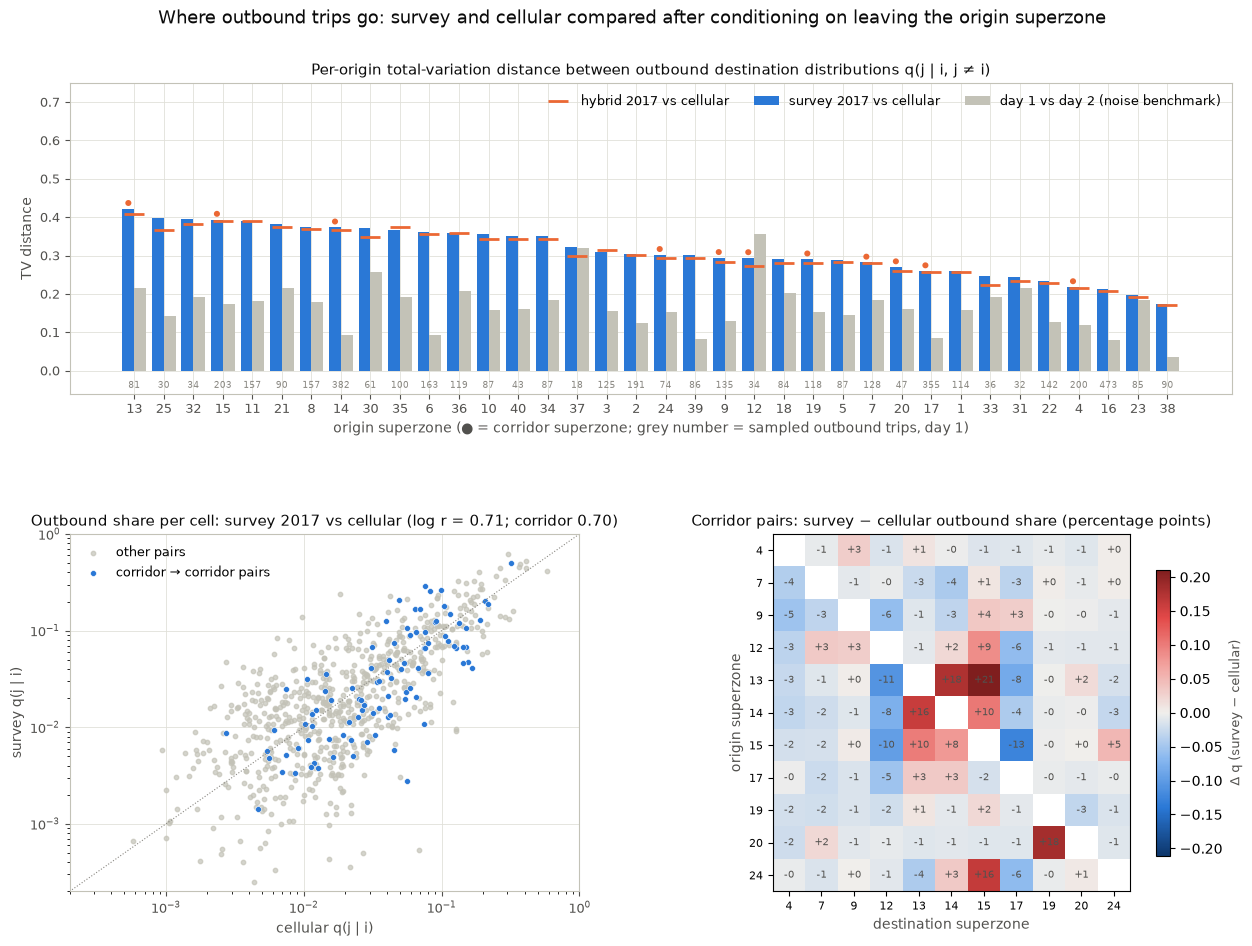

,survey 2018 d10 vs cellular,survey 2018 d20 vs cellular,day 10 vs day 20,survey 2017 vs cellular,day 1 vs day 2 (2017),hybrid 2017 vs cellular,hybrid 2017 vs survey 2017,sampled outbound trips (2017 d1),corridor
1,0.276,0.260,0.169,0.259,0.159,0.256,0.004,114.000,False
2,0.274,0.338,0.150,0.305,0.124,0.302,0.004,191.000,False
3,0.361,0.355,0.181,0.309,0.155,0.315,0.015,124.692,False
4,0.202,0.231,0.125,0.218,0.120,0.215,0.004,200.000,True
5,0.302,0.331,0.145,0.289,0.144,0.284,0.007,87.029,False
6,0.341,0.390,0.131,0.362,0.092,0.355,0.015,163.209,False
7,0.435,0.421,0.172,0.282,0.184,0.281,0.011,128.491,True
8,0.412,0.411,0.163,0.375,0.179,0.370,0.005,157.000,False
9,0.305,0.347,0.121,0.294,0.130,0.283,0.014,134.613,True
10,0.354,0.372,0.163,0.356,0.159,0.344,0.014,87.000,False


In [4]:
# cell-level view: outbound shares, survey vs cellular, all pairs and corridor-to-corridor pairs
qs, qc, qs2 = q_of(sz_s17), q_of(sz_cell), q_of(sz_s1)
qd2 = q_of(sz_s2)
off = ~np.eye(n, dtype=bool)
cc = np.outer(corr_mask, corr_mask) & off
def r_log(a, b, m, floor=1e-4):
    return np.corrcoef(np.log10(a[m] + floor), np.log10(b[m] + floor))[0, 1]
print(f"log-share correlation, all {off.sum()} off-diagonal cells: survey vs cellular {r_log(qs, qc, off):.3f}, day 1 vs day 2 {r_log(qs2, qd2, off):.3f}")
print(f"corridor-to-corridor ({cc.sum()} cells): survey vs cellular {r_log(qs, qc, cc):.3f}, day 1 vs day 2 {r_log(qs2, qd2, cc):.3f}")
print(f"share of outbound survey trips in cells where cellular gives < 0.5 %: {qs[off & (qc < 0.005)].sum() / qs[off].sum():.1%}")

order = np.argsort(-tv['survey 2017 vs cellular'].values)
fig = plt.figure(figsize=(15, 10.5), facecolor='white')
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.15], hspace=0.42, wspace=0.28)
ax = fig.add_subplot(gs[0, :])
xx = np.arange(n)
ax.bar(xx - 0.2, tv['survey 2017 vs cellular'].values[order], width=0.4, color=BLUE, label='survey 2017 vs cellular')
ax.bar(xx + 0.2, tv['day 1 vs day 2 (2017)'].values[order], width=0.4, color=AXIS, label='day 1 vs day 2 (noise benchmark)')
ax.plot(xx, tv['hybrid 2017 vs cellular'].values[order], color=ORANGE, lw=0, marker='_', ms=14, mew=2, label='hybrid 2017 vs cellular')
for k, i in enumerate(order):
    ax.text(k, -0.045, f"{n_out.values[i]:.0f}", ha='center', fontsize=6.5, color=MUTED)
    if corr_mask[i]: ax.text(k - 0.2, tv['survey 2017 vs cellular'].values[i] + 0.01, '●', ha='center', fontsize=6, color=ORANGE)
ax.set_xticks(xx, SZ[order], fontsize=8); ax.set_ylim(-0.06, 0.75)
style_ax(ax, 'Per-origin total-variation distance between outbound destination distributions q(j | i, j ≠ i)',
         'origin superzone (● = corridor superzone; grey number = sampled outbound trips, day 1)', 'TV distance')
ax.legend(frameon=False, fontsize=9, ncols=3, loc='upper right')

ax = fig.add_subplot(gs[1, 0])
ax.scatter(qc[off & ~cc], qs[off & ~cc], s=10, color=AXIS, alpha=0.7, label='other pairs')
ax.scatter(qc[cc], qs[cc], s=18, color=BLUE, edgecolors='white', linewidths=0.4, label='corridor → corridor pairs')
lim = (2e-4, 1); ax.plot(lim, lim, color=MUTED, lw=0.8, ls=':')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(lim); ax.set_ylim(lim)
style_ax(ax, f'Outbound share per cell: survey 2017 vs cellular (log r = {r_log(qs, qc, off):.2f}; corridor {r_log(qs, qc, cc):.2f})',
         'cellular q(j | i)', 'survey q(j | i)')
ax.legend(frameon=False, fontsize=9, loc='upper left')

ax = fig.add_subplot(gs[1, 1])
ci = [pos[z] for z in CORR_SZ]
D = (qs - qc)[np.ix_(ci, ci)]; np.fill_diagonal(D, np.nan)
vmax = np.nanmax(np.abs(D))
im = ax.imshow(D, cmap=CMAP_DIV, norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax))
for a in range(len(ci)):
    for b in range(len(ci)):
        if a != b: ax.text(b, a, f'{D[a, b] * 100:+.0f}', ha='center', va='center', fontsize=7, color=INK2)
ax.set_xticks(range(len(ci)), CORR_SZ, fontsize=8); ax.set_yticks(range(len(ci)), CORR_SZ, fontsize=8)
ax.set_xlabel('destination superzone', color=INK2); ax.set_ylabel('origin superzone', color=INK2)
ax.set_title('Corridor pairs: survey − cellular outbound share (percentage points)', color=INK, fontsize=11)
fig.colorbar(im, ax=ax, shrink=0.8).set_label('Δ q (survey − cellular)', color=INK2, fontsize=9)
fig.suptitle('Where outbound trips go: survey and cellular compared after conditioning on leaving the origin superzone', color=INK, fontsize=13, y=0.95)
save_show(fig, 'pca_review_outbound_test.png')
tv.round(3)

## 3. Household bootstrap of the 2017 trips file

Households are the survey's sampling units and both survey days of a household move together, so a replicate resamples households with replacement (with their two days), rebuilds the day-averaged superzone matrix, and recomputes: the Hungarian-matched congruence of each survey component with cellular's PC1–PC6, the survey's variance shares and participation ratio, the mean self-containment and the mean outbound TV distance to cellular. The percentile interval over replicates is the sampling uncertainty of each statistic **given the survey design** — it does not cover systematic bias in either source.

One caution in reading the intervals: a bootstrap replicate carries the original sample's noise *plus* resampling noise, so statistics that respond to noise in one direction — a congruence falls with noise, a distance rises with it — are biased in that direction under resampling. The bootstrap mean is reported next to the point estimate so the shift is visible; the interval width, not its position, is the sampling-uncertainty message.

In [5]:
B = 400
nH = len(hh_ids)
boot = {'phi': [], 'evr': [], 'pr': [], 'selfc': [], 'tv': [], 'tv_corr': []}
for b in range(B):
    mult = rng.multinomial(nH, np.full(nH, 1 / nH)).astype(float)
    M = (sz_counts(day[1], mult) + sz_counts(day[2], mult)) / 2
    P = M / M.sum(axis=1, keepdims=True)
    pc = pca(P)
    boot['phi'].append(match(pc)); boot['evr'].append(pc['evr'][:KC]); boot['pr'].append(part_ratio(pc['lam']))
    boot['selfc'].append(np.diag(P).mean())
    t_ = tv_rows(P, sz_cell); boot['tv'].append(t_.mean()); boot['tv_corr'].append(t_[corr_mask].mean())
boot = {k: np.array(v) for k, v in boot.items()}

pc17 = pca(sz_s17); phi17 = match(pc17)
def ci(a, axis=0): return np.percentile(a, [2.5, 97.5], axis=axis)
lo, hi = ci(boot['phi'])
band = lambda v: 'equal (≥ 0.95)' if v >= 0.95 else 'fair similarity (0.85–0.94)' if v >= 0.85 else 'below 0.85'
rows = []
for j in range(KC):
    rows.append({'cellular PC': j + 1, 'cellular var. share': PC_CELL['evr'][j],
                 '|φ| point': phi17[j], 'bootstrap mean': boot['phi'][:, j].mean(), '|φ| 2.5–97.5 %': f'{lo[j]:.2f}–{hi[j]:.2f}',
                 'reading (Lorenzo-Seva & ten Berge 2006)': band(phi17[j]), 'lower bound reading': band(lo[j]),
                 'survey var. share': pc17['evr'][j] if j < 4 else np.nan})
cong = pd.DataFrame(rows).set_index('cellular PC')
elo, ehi = ci(boot['evr'])
print(f"survey participation ratio {part_ratio(pc17['lam']):.1f} (95 % CI {ci(boot['pr'])[0]:.1f}–{ci(boot['pr'])[1]:.1f}); cellular {part_ratio(PC_CELL['lam']):.1f}")
print(f"top-4 variance share: survey {pc17['evr'][:4].sum():.2f} (CI {ci(boot['evr'][:, :4].sum(axis=1))[0]:.2f}–{ci(boot['evr'][:, :4].sum(axis=1))[1]:.2f}), cellular {PC_CELL['evr'][:4].sum():.2f}")
print(f"mean self-containment {np.diag(sz_s17.values).mean():.3f} (CI {ci(boot['selfc'])[0]:.3f}–{ci(boot['selfc'])[1]:.3f}); cellular {np.diag(sz_cell.values).mean():.3f}")
print(f"mean outbound TV vs cellular {tv['survey 2017 vs cellular'].mean():.3f} (bootstrap 2.5–97.5 %, biased upward: {ci(boot['tv'])[0]:.3f}–{ci(boot['tv'])[1]:.3f}); "
      f"corridor origins {tv.loc[corr_mask, 'survey 2017 vs cellular'].mean():.3f} (bootstrap: {ci(boot['tv_corr'])[0]:.3f}–{ci(boot['tv_corr'])[1]:.3f}); "
      f"day 1 vs day 2 benchmark {tv['day 1 vs day 2 (2017)'].mean():.3f}")
cong.round(3)

survey participation ratio 28.5 (95 % CI 27.6–28.9); cellular 13.1
top-4 variance share: survey 0.21 (CI 0.20–0.21), cellular 0.47
mean self-containment 0.683 (CI 0.669–0.696); cellular 0.336
mean outbound TV vs cellular 0.312 (bootstrap 2.5–97.5 %, biased upward: 0.341–0.374); corridor origins 0.309 (bootstrap: 0.323–0.377); day 1 vs day 2 benchmark 0.167


,cellular var. share,|φ| point,bootstrap mean,|φ| 2.5–97.5 %,reading (Lorenzo-Seva & ten Berge 2006),lower bound reading,survey var. share
cellular PC,,,,,,,
1,0.139,0.873,0.844,0.70–0.93,fair similarity (0.85–0.94),below 0.85,0.056
2,0.134,0.967,0.936,0.81–0.97,equal (≥ 0.95),below 0.85,0.053
3,0.109,0.839,0.817,0.68–0.92,below 0.85,below 0.85,0.050
4,0.085,0.901,0.854,0.71–0.92,fair similarity (0.85–0.94),below 0.85,0.047
5,0.073,0.705,0.554,0.07–0.89,below 0.85,below 0.85,NaN
6,0.059,0.464,0.450,0.04–0.83,below 0.85,below 0.85,NaN


## 4. What flattens the survey's eigenvalue spectrum — the diagonal or sampling noise?

The report claimed that sampling noise flattens the survey's spectrum while leaving its eigenvectors intact. The reviewer's objection is that a dominant diagonal can flatten a spectrum on its own. The two causes are separated by construction on the cellular matrix, which has neither problem:

- **diagonal only** — cellular with each row's self-share replaced by the survey's (p′_ii = s_i, off-diagonal rescaled to 1 − s_i), no noise;
- **noise only** — cellular resampled multinomially, origin by origin, at the survey's day-1 sample sizes;
- **both** — the diagonal-inflated matrix resampled the same way.

Each synthetic matrix is decomposed and compared with the survey's spectrum; the resampled matrices are also matched back to cellular, which gives the congruence that pure sampling noise at the survey's sample size would produce — the natural benchmark for the observed 0.85–0.97.

outbound TV benchmark under pure sampling noise at the survey's sample sizes: one sample vs truth 0.132, two samples vs each other 0.178 (observed day 1 vs day 2 0.167; survey vs cellular 0.312 = 2.4× the noise expectation)


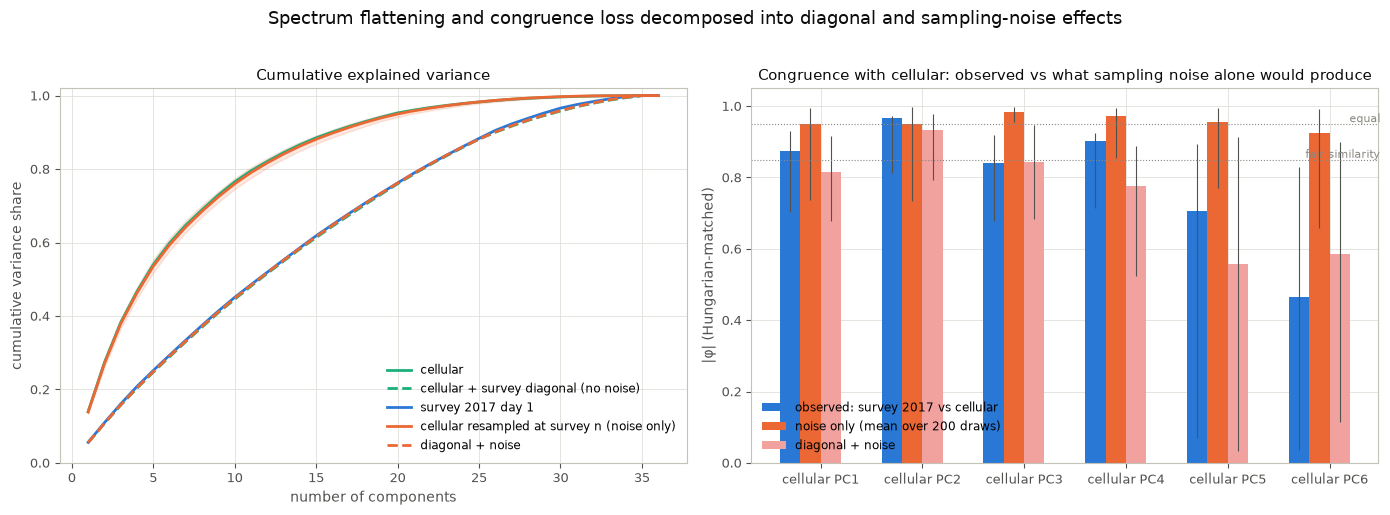

,top-4 variance share,participation ratio
cellular (observed),0.47,13.10
"cellular + survey diagonal, no noise",0.20,28.84
cellular resampled at survey n (noise only),0.46,13.27
diagonal + noise,0.20,28.72
survey 2017 day 1 (observed),0.21,28.50
survey 2017 day average (observed),0.21,28.46


,noise only: mean |φ| vs cellular,noise only: 2.5 %,diagonal + noise: mean |φ|,diagonal + noise: 2.5 %,observed survey 2017 |φ|
PC1,0.949,0.737,0.815,0.678,0.873
PC2,0.950,0.734,0.934,0.792,0.967
PC3,0.984,0.956,0.844,0.684,0.839
PC4,0.974,0.854,0.776,0.525,0.901
PC5,0.956,0.771,0.557,0.033,0.705
PC6,0.925,0.658,0.586,0.115,0.464


In [6]:
s17 = np.diag(sz_s17.values)
Pc = sz_cell.values
def with_survey_diag(P, s):
    A = P.copy(); np.fill_diagonal(A, 0)
    A = A / A.sum(axis=1, keepdims=True) * (1 - s)[:, None]
    A[np.arange(n), np.arange(n)] = s
    return A
Pdiag = with_survey_diag(Pc, s17)
def resample(P, sizes, r):
    return np.vstack([r.multinomial(int(round(sizes[i])), P[i]) / max(int(round(sizes[i])), 1) for i in range(n)])
R = 200
noise_only, both = [], []
for _ in range(R):
    noise_only.append(resample(Pc, n_all.values, rng)); both.append(resample(Pdiag, n_all.values, rng))
tv_noise_truth = np.mean([tv_rows(P, Pc).mean() for P in noise_only])
tv_noise_pair = np.mean([tv_rows(noise_only[i], noise_only[i + 1]).mean() for i in range(0, R - 1, 2)])
print(f"outbound TV benchmark under pure sampling noise at the survey's sample sizes: one sample vs truth {tv_noise_truth:.3f}, "
      f"two samples vs each other {tv_noise_pair:.3f} (observed day 1 vs day 2 {tv['day 1 vs day 2 (2017)'].mean():.3f}; "
      f"survey vs cellular {tv['survey 2017 vs cellular'].mean():.3f} = {tv['survey 2017 vs cellular'].mean() / tv_noise_truth:.1f}× the noise expectation)")
def spec_stats(P):
    pc = pca(P); return pc['evr'][:4].sum(), part_ratio(pc['lam'])
cases = {
    'cellular (observed)': [spec_stats(Pc)],
    'cellular + survey diagonal, no noise': [spec_stats(Pdiag)],
    'cellular resampled at survey n (noise only)': [spec_stats(P) for P in noise_only],
    'diagonal + noise': [spec_stats(P) for P in both],
    'survey 2017 day 1 (observed)': [spec_stats(sz_s1.values)],
    'survey 2017 day average (observed)': [spec_stats(sz_s17.values)],
}
spec = pd.DataFrame({k: {'top-4 variance share': np.mean([v[0] for v in vals]), 'participation ratio': np.mean([v[1] for v in vals])}
                     for k, vals in cases.items()}).T.round(2)
phi_noise = np.array([match(pca(P)) for P in noise_only]); phi_both = np.array([match(pca(P)) for P in both])
spec_phi = pd.DataFrame({'noise only: mean |φ| vs cellular': phi_noise.mean(axis=0), 'noise only: 2.5 %': np.percentile(phi_noise, 2.5, axis=0),
                         'diagonal + noise: mean |φ|': phi_both.mean(axis=0), 'diagonal + noise: 2.5 %': np.percentile(phi_both, 2.5, axis=0),
                         'observed survey 2017 |φ|': phi17}, index=[f'PC{j+1}' for j in range(KC)]).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
ax = axes[0]
for name, P, col, ls in [('cellular', Pc, AQUA, '-'), ('cellular + survey diagonal (no noise)', Pdiag, AQUA, '--'),
                         ('survey 2017 day 1', sz_s1.values, BLUE, '-')]:
    ax.plot(range(1, 37), np.cumsum(pca(P)['evr']), color=col, ls=ls, lw=2, label=name)
cum_noise = np.array([np.cumsum(pca(P)['evr']) for P in noise_only]); cum_both = np.array([np.cumsum(pca(P)['evr']) for P in both])
ax.plot(range(1, 37), cum_noise.mean(axis=0), color=ORANGE, lw=2, label='cellular resampled at survey n (noise only)')
ax.fill_between(range(1, 37), np.percentile(cum_noise, 2.5, axis=0), np.percentile(cum_noise, 97.5, axis=0), color=ORANGE, alpha=0.15)
ax.plot(range(1, 37), cum_both.mean(axis=0), color=ORANGE, ls='--', lw=2, label='diagonal + noise')
ax.set_ylim(0, 1.02); style_ax(ax, 'Cumulative explained variance', 'number of components', 'cumulative variance share')
ax.legend(frameon=False, fontsize=8.5, loc='lower right')
ax = axes[1]
xx = np.arange(KC)
ax.bar(xx - 0.3, phi17, width=0.2, color=BLUE, label='observed: survey 2017 vs cellular')
ax.bar(xx - 0.1, phi_noise.mean(axis=0), width=0.2, color=ORANGE, label='noise only (mean over 200 draws)')
ax.bar(xx + 0.1, phi_both.mean(axis=0), width=0.2, color='#f2a29e', label='diagonal + noise')
ax.errorbar(xx - 0.1, phi_noise.mean(axis=0), yerr=[phi_noise.mean(axis=0) - np.percentile(phi_noise, 2.5, axis=0), np.percentile(phi_noise, 97.5, axis=0) - phi_noise.mean(axis=0)], fmt='none', ecolor=INK2, lw=0.8)
ax.errorbar(xx + 0.1, phi_both.mean(axis=0), yerr=[phi_both.mean(axis=0) - np.percentile(phi_both, 2.5, axis=0), np.percentile(phi_both, 97.5, axis=0) - phi_both.mean(axis=0)], fmt='none', ecolor=INK2, lw=0.8)
ax.errorbar(xx - 0.3, phi17, yerr=[phi17 - lo, hi - phi17], fmt='none', ecolor=INK2, lw=0.8)
ax.axhline(0.95, color=MUTED, lw=0.8, ls=':'); ax.axhline(0.85, color=MUTED, lw=0.8, ls=':')
ax.text(KC - 0.5, 0.955, 'equal', color=MUTED, fontsize=8, ha='right'); ax.text(KC - 0.5, 0.855, 'fair similarity', color=MUTED, fontsize=8, ha='right')
ax.set_xticks(xx, [f'cellular PC{j+1}' for j in range(KC)], fontsize=9); ax.set_ylim(0, 1.05)
style_ax(ax, 'Congruence with cellular: observed vs what sampling noise alone would produce', None, '|φ| (Hungarian-matched)')
ax.legend(frameon=False, fontsize=8.5, loc='lower left')
fig.suptitle('Spectrum flattening and congruence loss decomposed into diagonal and sampling-noise effects', color=INK, fontsize=13, y=1.02)
plt.tight_layout(); save_show(fig, 'pca_review_noise_decomposition.png')
display(spec); spec_phi

## 5. Diagonal audit — what is an intra-superzone survey trip?

The ≈ 68–72 % survey self-containment is the quantity the correction factors carry into the hybrid, so it must be real travel, not a processing artefact. The trips file records for each trip its origin and destination activity (`mainActivity`, 1 = Home), its zone (`actTaz`, the national 2636-zone system, finer than the study superzones) and a reported distance (`TrvlDist`, km, missing for 22 % of activity rows). Intra-superzone AM-peak trips are profiled against inter-superzone ones. A trip cannot arise from "staying at home": a trip row exists only when consecutive activities are recorded in sequence, and a home → home pair with the same zone is flagged separately below.

intra-superzone trips: 73.5% of weighted AM-peak trips; of these 48% start and end in the same 2636-zone, 52% cross a 2636-zone boundary


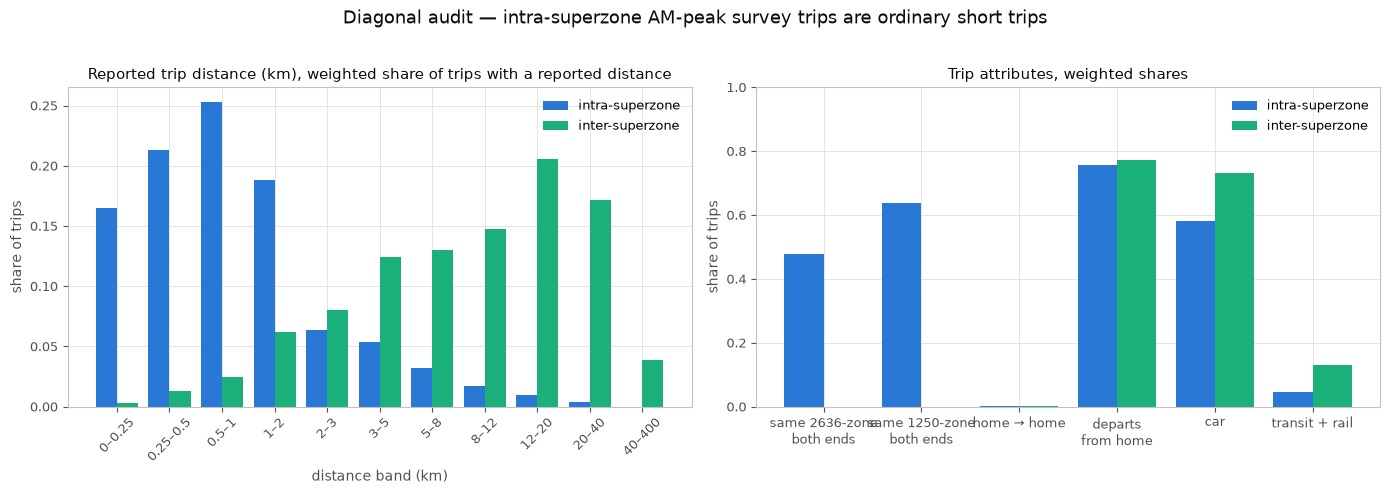

,intra-superzone,inter-superzone
share of AM trips (weighted),0.735,0.265
sampled trips,19149.000,7686.000
same actTaz (2636-zone) both ends,0.479,0.000
same 1250-zone both ends,0.638,0.000
home → home,0.002,0.001
departs from home,0.755,0.773
distance reported,1.000,1.000
median reported distance (km),0.700,9.511
reported distance < 0.5 km,0.378,0.016
reported distance ≥ 2 km,0.181,0.897


,inter-superzone,intra-superzone
pair,,
1→4,0.162,0.386
1→11,0.041,0.149
1→2,0.433,0.134
11→1,0.010,0.044
11→11,0.009,0.035
11→4,0.010,0.035
1→6,0.040,0.032
11→2,0.063,0.029


In [7]:
tr['O'] = tr['o1250'].map(A_o.groupby('ARZI_1270')['SUPERZONE'].first())   # dominant superzone, for profiling only
tr['D'] = tr['d1250'].map(A_d.groupby('ARZI_1270')['SUPERZONE'].first())
tr['intra_sz'] = tr['O'] == tr['D']
tr['same_actTaz'] = tr['origin'] == tr['destination']
tr['same_1250'] = tr['o1250'] == tr['d1250']
tr['home_home'] = (tr['o_act'] == 1) & (tr['d_act'] == 1)
tr['from_home'] = tr['o_act'] == 1
tr['dist_known'] = tr['TrvlDist'].notna()
w = tr['new_wf']
def wshare(mask, base):
    return w[mask & base].sum() / w[base].sum()
rows = {}
for lbl, base in [('intra-superzone', tr['intra_sz']), ('inter-superzone', ~tr['intra_sz'])]:
    sub_ = tr[base]; ww = w[base]
    known = sub_['dist_known']
    dist = sub_.loc[known, 'TrvlDist']; wd = ww[known]
    o = np.argsort(dist.values); cw = np.cumsum(wd.values[o]) / wd.sum()
    med = dist.values[o][np.searchsorted(cw, 0.5)]
    rows[lbl] = {'share of AM trips (weighted)': ww.sum() / w.sum(), 'sampled trips': len(sub_),
                 'same actTaz (2636-zone) both ends': wshare(tr['same_actTaz'], base), 'same 1250-zone both ends': wshare(tr['same_1250'], base),
                 'home → home': wshare(tr['home_home'], base), 'departs from home': wshare(tr['from_home'], base),
                 'distance reported': wshare(tr['dist_known'], base), 'median reported distance (km)': med,
                 'reported distance < 0.5 km': (wd[dist < 0.5].sum() / wd.sum()), 'reported distance ≥ 2 km': (wd[dist >= 2].sum() / wd.sum()),
                 'car share': wshare(tr['mode'] == 'CAR', base), 'transit + rail share': wshare(tr['mode'].isin(['TRANSIT', 'RAIL']), base)}
audit = pd.DataFrame(rows)
print(f"intra-superzone trips: {audit.loc['share of AM trips (weighted)', 'intra-superzone']:.1%} of weighted AM-peak trips; "
      f"of these {audit.loc['same actTaz (2636-zone) both ends', 'intra-superzone']:.0%} start and end in the same 2636-zone, "
      f"{1 - audit.loc['same actTaz (2636-zone) both ends', 'intra-superzone']:.0%} cross a 2636-zone boundary")
acts = (tr.assign(pair=tr['o_act'].astype(int).astype(str) + '→' + tr['d_act'].astype(int).astype(str))
          .groupby(['intra_sz', 'pair'])['new_wf'].sum().unstack(0).fillna(0))
acts = (acts / acts.sum()).sort_values(True, ascending=False).head(8).round(3)
acts.columns = ['inter-superzone', 'intra-superzone']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), facecolor='white')
ax = axes[0]
bins = np.array([0, 0.25, 0.5, 1, 2, 3, 5, 8, 12, 20, 40, 400])
for lbl, base, col in [('intra-superzone', tr['intra_sz'], BLUE), ('inter-superzone', ~tr['intra_sz'], AQUA)]:
    sub_ = tr[base & tr['dist_known']]
    h, _ = np.histogram(sub_['TrvlDist'], bins=bins, weights=sub_['new_wf']); h = h / h.sum()
    ax.bar(np.arange(len(h)) + (-0.2 if lbl.startswith('intra') else 0.2), h, width=0.4, color=col, label=lbl)
ax.set_xticks(np.arange(len(bins) - 1), [f'{a:g}–{b:g}' for a, b in zip(bins[:-1], bins[1:])], fontsize=8, rotation=45)
style_ax(ax, 'Reported trip distance (km), weighted share of trips with a reported distance', 'distance band (km)', 'share of trips')
ax.legend(frameon=False, fontsize=9)
ax = axes[1]
lab = ['same 2636-zone\nboth ends', 'same 1250-zone\nboth ends', 'home → home', 'departs\nfrom home', 'car', 'transit + rail']
keys = ['same actTaz (2636-zone) both ends', 'same 1250-zone both ends', 'home → home', 'departs from home', 'car share', 'transit + rail share']
xx = np.arange(len(lab))
ax.bar(xx - 0.2, audit.loc[keys, 'intra-superzone'], width=0.4, color=BLUE, label='intra-superzone')
ax.bar(xx + 0.2, audit.loc[keys, 'inter-superzone'], width=0.4, color=AQUA, label='inter-superzone')
ax.set_xticks(xx, lab, fontsize=8); ax.set_ylim(0, 1)
style_ax(ax, 'Trip attributes, weighted shares', None, 'share of trips'); ax.legend(frameon=False, fontsize=9)
fig.suptitle('Diagonal audit — intra-superzone AM-peak survey trips are ordinary short trips', color=INK, fontsize=13, y=1.02)
plt.tight_layout(); save_show(fig, 'pca_review_diagonal_audit.png')
display(audit.round(3)); acts

## 6. Within-superzone exposure of the corridor, and a check at the survey's native resolution

Superzone-level agreement leaves the allocation of trips *inside* a superzone to cellular. How much of the corridor's demand that concerns is measured first on the hybrid TAZ matrix (corridor = the 119 LRT-corridor TAZs). Then, at the finest resolution where the survey is not itself allocated by cellular shares — the survey records `actTaz` in the 2636-zone system, mapped one-to-one to the 1250-zone system, and only the last link to study TAZs is a cellular-share allocation — the destination distribution of intra-superzone trips is compared between survey and cellular for each corridor superzone, pooled over the superzone's origins. Cellular at 1250-zone resolution is aggregated from `prob_matrix_cellular.csv` with hybrid TAZ outflows as origin weights (destination aggregation is exact).

In [8]:
corr_in = [t_ for t_ in corr_taz if t_ in hyb_taz.index]
Hc = hyb_taz.loc[corr_in, corr_in].values
same_sz = (taz_sz.reindex(corr_in).values[:, None] == taz_sz.reindex(corr_in).values[None, :])
cor_total = Hc.sum()
print(f"hybrid AM-peak trips with both ends in the corridor: {cor_total:,.0f} = {cor_total / hyb_taz.values.sum():.1%} of the study area; "
      f"of these {Hc[same_sz].sum() / cor_total:.0%} stay inside one superzone and {np.trace(Hc) / cor_total:.0%} inside one TAZ")
sv_taz = load_prob('Output/ths2017/study_taz/matrix_avg_ALL_taz.csv')
Sc = sv_taz.loc[corr_in, corr_in].values
print(f"survey 2017 (allocated TAZ matrix), same corridor cells: {Sc.sum():,.0f} trips, {Sc[same_sz].sum() / Sc.sum():.0%} intra-superzone, {np.trace(Sc) / Sc.sum():.0%} intra-TAZ")

# cellular at 1250-zone resolution (rows weighted by hybrid TAZ outflow), survey at native 1250 resolution
cell_taz = load_prob('Output/prob_matrix_cellular.csv')
taz_1250 = shp.set_index('TAZ_NUMBER')['ARZI_1270']
wout = hyb_taz.sum(axis=1)
C = cell_taz.mul(wout, axis=0)
C1250 = C.groupby(taz_1250.reindex(C.index).values).sum().T.groupby(taz_1250.reindex(C.columns).values).sum().T
C1250 = C1250.div(C1250.sum(axis=1), axis=0)
sv1250 = x.groupby(['o1250', 'd1250'])['new_wf'].sum().unstack().fillna(0) / 2          # day-averaged weights
smp1250 = x.groupby(['o1250', 'd1250']).size().unstack().fillna(0)
z_sz = A_o.groupby('ARZI_1270')['SUPERZONE'].first()
rows = []
for z in CORR_SZ:
    zones = [k for k in z_sz.index[z_sz == z] if k in C1250.index and k in sv1250.index]
    if len(zones) < 3: continue
    sub_s = sv1250.reindex(index=zones, columns=zones, fill_value=0)
    pooled_s = sub_s.sum(axis=0); pooled_s = pooled_s / pooled_s.sum()
    wrow = sub_s.sum(axis=1)                                   # survey origin weights inside the superzone
    sub_c = C1250.loc[zones, zones]
    sub_c = sub_c.div(sub_c.sum(axis=1), axis=0).fillna(0)
    pooled_c = (sub_c.mul(wrow, axis=0)).sum(axis=0); pooled_c = pooled_c / pooled_c.sum()
    nsmp = smp1250.reindex(index=zones, columns=zones, fill_value=0).values.sum()
    rows.append({'superzone': z, '1250-zones': len(zones), 'sampled intra-SZ trips': int(nsmp),
                 'TV survey vs cellular': 0.5 * np.abs(pooled_s - pooled_c).sum(),
                 'r (destination shares)': np.corrcoef(pooled_s, pooled_c)[0, 1],
                 'largest survey dest. share': pooled_s.max(), 'same zone in cellular': pooled_c[pooled_s.idxmax()]})
within = pd.DataFrame(rows).set_index('superzone').round(3)
print(f"\nwithin-superzone destination check, corridor superzones with ≥ 3 native zones: mean TV {within['TV survey vs cellular'].mean():.2f}, "
      f"mean r {within['r (destination shares)'].mean():.2f} (sampled intra-SZ trips {within['sampled intra-SZ trips'].min()}–{within['sampled intra-SZ trips'].max()})")
within

hybrid AM-peak trips with both ends in the corridor: 94,610 = 4.6% of the study area; of these 71% stay inside one superzone and 23% inside one TAZ
survey 2017 (allocated TAZ matrix), same corridor cells: 110,641 trips, 75% intra-superzone, 33% intra-TAZ



within-superzone destination check, corridor superzones with ≥ 3 native zones: mean TV 0.22, mean r 0.81 (sampled intra-SZ trips 78–1597)


,1250-zones,sampled intra-SZ trips,TV survey vs cellular,r (destination shares),largest survey dest. share,same zone in cellular
superzone,,,,,,
4,6,939,0.202,0.979,0.369,0.533
7,9,315,0.314,0.876,0.354,0.591
9,11,514,0.258,0.731,0.371,0.219
12,12,78,0.141,0.954,0.321,0.381
13,6,368,0.072,0.994,0.739,0.708
14,7,1597,0.077,0.987,0.333,0.339
15,12,325,0.336,0.661,0.317,0.230
17,11,831,0.176,0.874,0.258,0.188
19,15,699,0.318,0.270,0.159,0.153


## 7. Scale — what the absolute totals rest on

PCA on row-normalised shares says nothing about volumes, and the reviewer is right that the report implied more. The pipeline's position on scale is simple and should be stated as such: **cellular enters only as probabilities** (`prob_*` files); every absolute number in the hybrid is the survey's expanded total. The check that can be made from the working copy is the consistency of those totals across the two extractions and the two days; the comparison with the cellular volumes themselves needs the raw cellular file (Git LFS, not present here) and is listed as an open item.

In [9]:
tot = pd.DataFrame({
    'sampled trips': [14078, 13982, 14420, 14197],
    'expanded AM-peak trips': [2196813, 2172451, 2193422, 2163320]},
    index=['2017 trips file, day 1', '2017 trips file, day 2', '2018 activities, day 10', '2018 activities, day 20'])
tot['weight per sampled trip'] = (tot['expanded AM-peak trips'] / tot['sampled trips']).round(1)
o1, o2 = cnt1.sum(axis=1), cnt2.sum(axis=1)
print(f"study-area avg-weekday total carried into the hybrid: {(cnt1 + cnt2).sum() / 2:,.0f}; hybrid_sz_trips total "
      f"{load_prob('Output/ths2017/study_taz/hybrid_sz_trips.csv').values.sum():,.0f}")
print(f"origin totals by superzone, day 1 vs day 2: median |Δ| / mean = {np.median(np.abs(o1 - o2) / ((o1 + o2) / 2)):.1%}, "
      f"max = {np.max(np.abs(o1 - o2) / ((o1 + o2) / 2)):.1%}")
tot

study-area avg-weekday total carried into the hybrid: 2,066,271; hybrid_sz_trips total 2,068,158
origin totals by superzone, day 1 vs day 2: median |Δ| / mean = 4.2%, max = 30.6%


,sampled trips,expanded AM-peak trips,weight per sampled trip
"2017 trips file, day 1",14078,2196813,156.0
"2017 trips file, day 2",13982,2172451,155.4
"2018 activities, day 10",14420,2193422,152.1
"2018 activities, day 20",14197,2163320,152.4


## 8. Findings

**1. Outbound destination choice differs between the sources by more than noise — the divergence is not only on the diagonal.** Conditioning on leaving the origin superzone, the mean total-variation distance between survey and cellular destination distributions is 0.31 (2017 trips file) and 0.34 (2018 activities file) — about 31–34 % of outbound trips would have to be moved between destinations to turn one into the other. Two survey days differ by 0.16–0.17, and pure multinomial sampling at the survey's per-origin sample sizes would put a single sample 0.13 from the truth (and two samples 0.18 apart, matching the observed day-to-day 0.17). The survey-to-cellular distance is therefore ≈ 2.4 × the noise expectation, similarly for corridor origins (0.31) and for origins with ≥ 100 sampled outbound trips (0.31 vs 0.14 day-to-day). The earlier statement that "88 % of squared divergence lies on the diagonal" remains arithmetically true but is dominated by the diagonal's magnitude; it does not license "the sources agree on where outbound trips go". Cell by cell, log-share correlation is 0.71 (day-to-day 0.81); in the corridor the survey routes markedly more of the Haifa inner-city exchange between superzones 13, 14 and 15 (+10 to +21 points) and less to the port / Hamifrats superzone 12 (−6 to −11) and from 15 to 17 (−13) than cellular does.

**2. The hybrid carries the survey's outbound pattern, not cellular's.** The hybrid's outbound distributions sit 0.015 from the survey's and 0.30 from cellular's: with k* = 5 the empirical-Bayes shrinkage is slight, and the correction factors R_AB act on every superzone pair, so at superzone level the hybrid is essentially the survey. Cellular's contribution is the allocation of trips to TAZs *within* each superzone pair. The question for validation is thus not "does the hybrid keep cellular's outbound structure" but "is the survey's superzone-to-superzone pattern, at 60–470 sampled outbound trips per origin, the better estimate" — a question the day-to-day cross-validation answers only against the survey itself.

**3. The survey's flat spectrum is the diagonal's doing, not sampling noise — the report's claim to the contrary is withdrawn.** Replacing cellular's self-shares by the survey's, with no noise at all, reproduces the survey spectrum exactly (top-4 share 0.20 vs 0.21, participation ratio 28.8 vs 28.5); resampling cellular at the survey's sample sizes leaves the spectrum untouched (0.46, 13.3). The reviewer's objection was correct.

**4. What the congruences do and do not show.** Under Lorenzo-Seva & ten Berge's bands only the north–south component (PC2, |φ| = 0.97) reaches "equal"; PC1 and PC4 (0.87, 0.90) are "fair similarity" and PC3 (0.84) sits below it. Household-bootstrap spreads are wide (PC1 0.70–0.93, PC3 0.68–0.92), so none of the four is established as identical. Two benchmarks locate the observed values: pure sampling noise at the survey's size would leave congruences at 0.95–0.98, so the shortfall is structural; and cellular given the survey's diagonal plus noise lands at 0.82 / 0.93 / 0.84 / 0.78 — the same level as the survey. The leading eigenvectors are thus consistent with "cellular's regional patterns, re-weighted by a much larger diagonal, plus noise", which is a weaker statement than the first report made and the right one.

**5. The diagonal is made of real, short trips.** Intra-superzone trips are 73.5 % of weighted AM-peak survey trips (mean self-containment 0.68, bootstrap 0.67–0.70; cellular 0.34). They are not stay-at-home artefacts (0.2 % home → home; 76 % depart from home, the same as inter-superzone trips) and are recorded at the survey's native 2636-zone resolution, where 52 % cross a zone boundary. They are short: median reported distance 0.7 km, 38 % under 0.5 km, only 18 % of 2 km or more (inter-superzone: median 9.5 km, 90 % ≥ 2 km); 58 % by car, 4.5 % by transit. This supports the diagonal correction's rationale (cellular under-detects short trips) while bounding its relevance to LRT: most of the trips it adds are below any plausible rail trip length, and the distance-band stratification of the mode-share step is what keeps them out of the LRT market. Whether their *magnitude* is right cannot be settled from the survey alone.

**6. Within-superzone allocation — the corridor's main exposure — is partly checkable and partly not.** 71 % of hybrid trips with both ends in the LRT corridor stay inside one superzone (23 % inside one TAZ), so cellular's within-superzone allocation governs most of the corridor's demand. At the survey's native 1250-zone resolution, pooled intra-superzone destination distributions agree well with cellular in the Haifa inner-city and Carmel superzones (13, 14, 4, 12: r ≥ 0.95, TV ≤ 0.20) and poorly in 19 (Nazareth, r = 0.27), 15, 9 and 24 (r 0.66–0.73, TV 0.26–0.34), on 78–1,600 sampled trips per superzone. Below 1250-zone resolution the survey is itself allocated by cellular shares and cannot check anything.

**7. Scale rests entirely on the survey.** Cellular enters the pipeline only as probabilities; every absolute number is the survey's expansion (2.07 M study-area AM-peak trips, day-to-day origin totals within a median 4 %). The cellular volumes have not been compared with these totals in this repository (raw file in Git LFS); the two extractions of the same panel agree within 0.5 %, which is a consistency check, not validation.

**What this changes in the case for the hybrid.** The structural evidence is weaker than the first report claimed: the sources share the north–south pattern and, more loosely, the core-vs-periphery and regional contrasts; they differ materially in where outbound trips go, and the hybrid resolves that difference by taking the survey's side on every superzone pair. The design remains defensible — the survey's superzone rows are estimated from 65–890 sampled trips each and the day-to-day cross-validation prefers them to cellular — but the report's conclusion must be the reviewer's: structural plausibility at superzone level is supported; absolute volumes, within-superzone allocation outside the inner-city superzones, and corridor suitability remain to be validated against evidence not used in the correction.